# Matplotlib & Seaborn — Essentials for AI/ML

This notebook covers the **minimum required content** of Matplotlib and Seaborn that you will repeatedly use in machine learning workflows: exploring data, visualizing distributions, relationships, correlations, and evaluating models.


## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Inline display in Jupyter
%matplotlib inline

# Global style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (7, 4)

np.random.seed(42)

## 2. Matplotlib Basics — Figure & Axes

Matplotlib has two key objects:
- **Figure**: the whole canvas
- **Axes**: an individual plot inside the figure

The object-oriented style (`fig, ax = plt.subplots()`) is recommended.

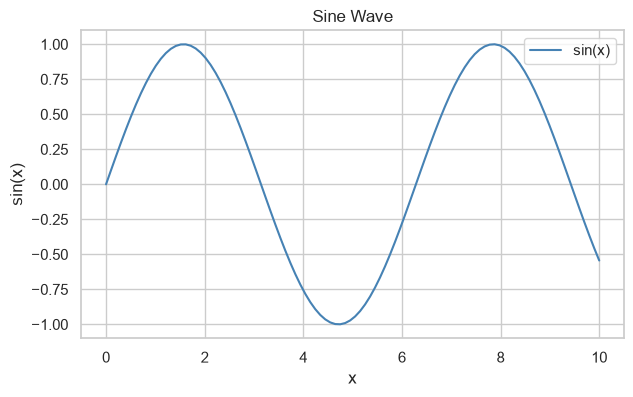

In [2]:
x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, ax = plt.subplots()
ax.plot(x, y, label="sin(x)", color="steelblue")
ax.set_title("Sine Wave")
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")
ax.legend()
plt.show()

## 3. Common Plots

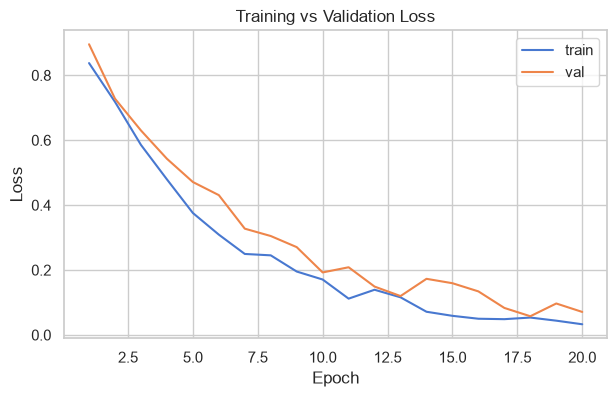

In [3]:
# Line plot — useful for training/loss curves
epochs = np.arange(1, 21)
train_loss = np.exp(-epochs/5) + np.random.rand(20)*0.05 #train_loss = decreasing_curve + small_noise
val_loss   = np.exp(-epochs/6) + np.random.rand(20)*0.08 #train_loss = decreasing_curve_more_slowly + larger_noise

#Validation loss is usually noisier than training loss.

plt.plot(epochs, train_loss, label="train")
plt.plot(epochs, val_loss, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

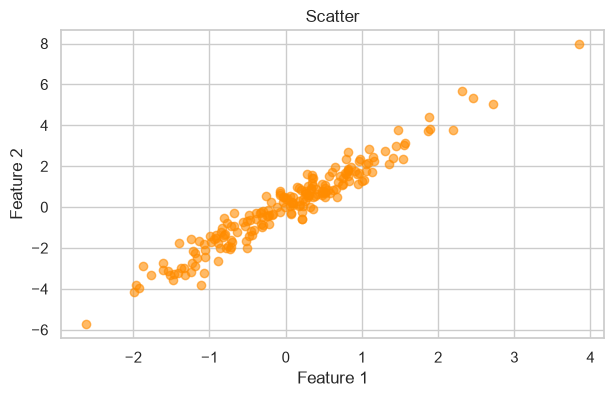

In [4]:
# Scatter — relationship between two features
x = np.random.randn(200)
y = 2*x + np.random.randn(200)*0.5 

#y = 2x + e(noise or error)
# where e ~ N(0,0.5^2)

plt.scatter(x, y, alpha=0.6, c="darkorange")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2"); plt.title("Scatter")
plt.show()

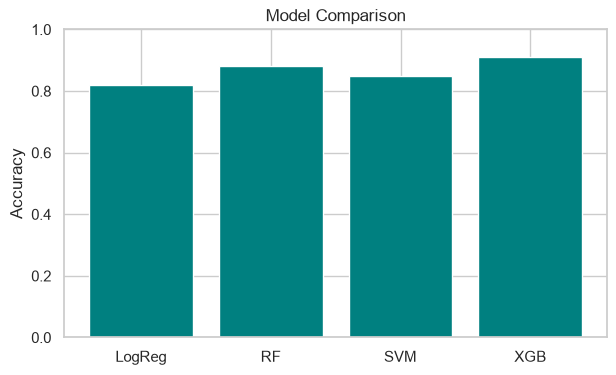

In [11]:
# Bar — comparing categories (e.g., model accuracies)
models = ["LogReg", "RF", "SVM", "XGB"]
acc    = [0.82, 0.88, 0.85, 0.91]
plt.bar(models, acc, color="teal")
plt.ylabel("Accuracy"); plt.title("Model Comparison")
plt.ylim(0, 1)
plt.show()

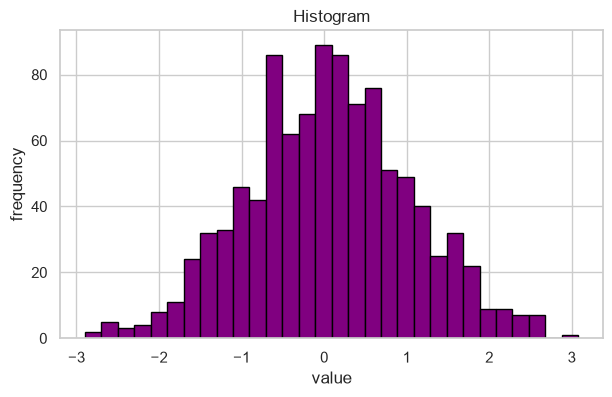

In [12]:
# Histogram — distribution of a feature
data = np.random.randn(1000)
plt.hist(data, bins=30, color="purple", edgecolor="black")
plt.title("Histogram"); plt.xlabel("value"); plt.ylabel("frequency")
plt.show()

## 4. Subplots — Multiple Plots in One Figure

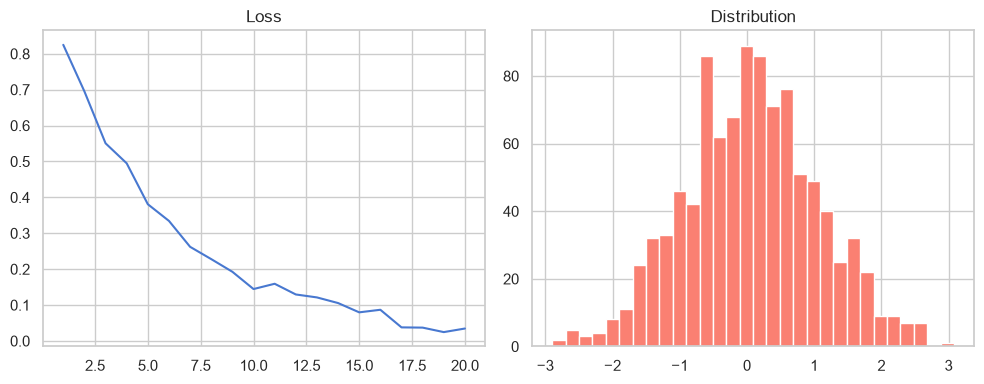

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(epochs, train_loss); axes[0].set_title("Loss")
axes[1].hist(data, bins=30, color="salmon"); axes[1].set_title("Distribution")

plt.tight_layout()
plt.show()

## 5. Seaborn Basics

Seaborn is built on top of Matplotlib but provides:
- Beautiful defaults
- Direct support for pandas DataFrames
- High-level statistical plots

We'll use the built-in **iris** and **tips** datasets.

In [6]:
iris = sns.load_dataset("iris")
tips = sns.load_dataset("tips")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 6. Distribution Plots

In iris data, there are 3 categories: setosa, versicolor, virginica

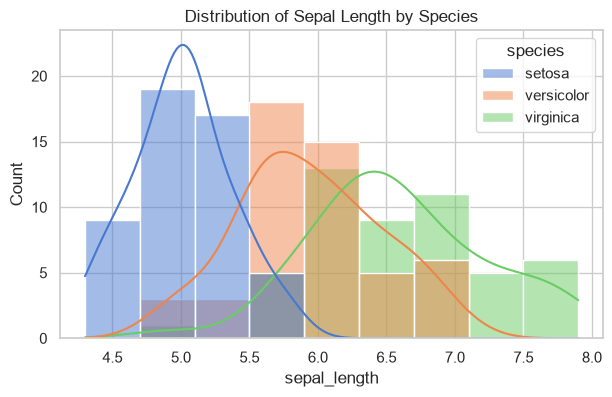

In [7]:
sns.histplot(data=iris, x="sepal_length", kde=True, hue="species")
plt.title("Distribution of Sepal Length by Species")
plt.show()

#kde = kernel density estimation -> it draws a smooth curve showing distribution of the data.

#hue -> is used to filter categories

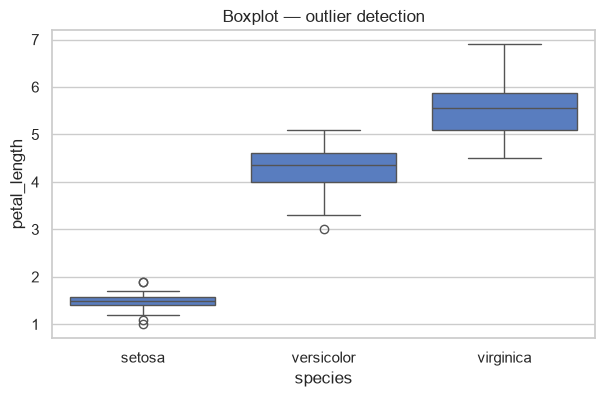

In [8]:
sns.boxplot(data=iris, x="species", y="petal_length")
plt.title("Boxplot — outlier detection")
plt.show()

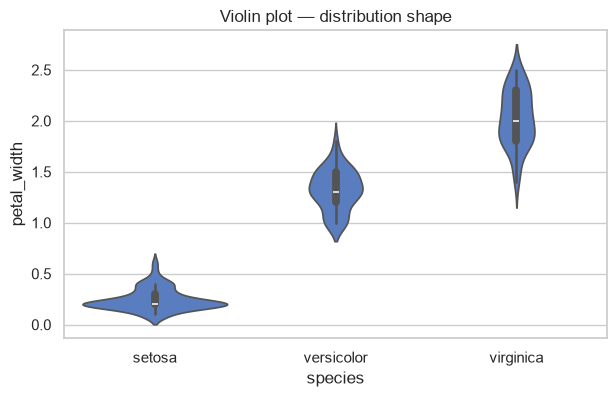

In [9]:
sns.violinplot(data=iris, x="species", y="petal_width")
plt.title("Violin plot — distribution shape")
plt.show()

### Violin Plot

A violin plot shows the **distribution** of a numerical variable across different categories. It combines a **box plot** with a **density plot (KDE)**.

- **Wider sections** indicate a higher concentration of data points.
- **Narrower sections** indicate fewer data points.
- The **white dot** represents the median.
- The **thick bar** represents the interquartile range (IQR).

In this plot, petal widths differ significantly among the three Iris species:

- **Setosa** has the smallest petal widths.
- **Versicolor** has moderate petal widths.
- **Virginica** has the largest petal widths.

This suggests that **petal width is a useful feature for distinguishing Iris species**.

## 7. Relationship Plots

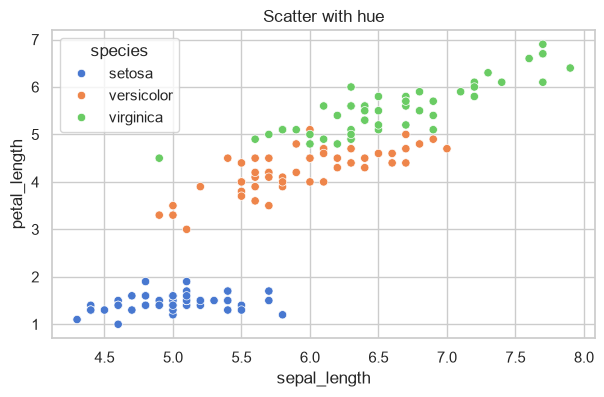

In [16]:
sns.scatterplot(data=iris, x="sepal_length", y="petal_length", hue="species")
plt.title("Scatter with hue")
plt.show()

In [ ]:
# Pairplot — quick EDA showing all pairwise feature relationships
sns.pairplot(iris, hue="species", height=1.8)
plt.show()

In [ ]:
sns.jointplot(data=iris, x="sepal_length", y="petal_length",
              hue="species", kind="scatter")
plt.show()

## 8. Categorical Plots

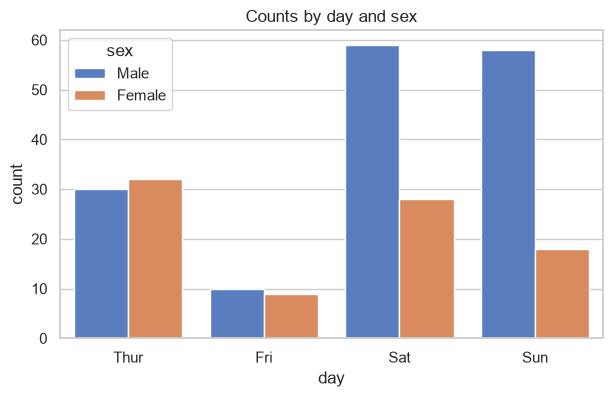

In [17]:
sns.countplot(data=tips, x="day", hue="sex")
plt.title("Counts by day and sex")
plt.show()

In [ ]:
sns.barplot(data=tips, x="day", y="total_bill", hue="sex", estimator=np.mean)
plt.title("Mean total bill by day")
plt.show()

## 9. Heatmap — Correlation Matrix

Crucial for feature selection in ML.

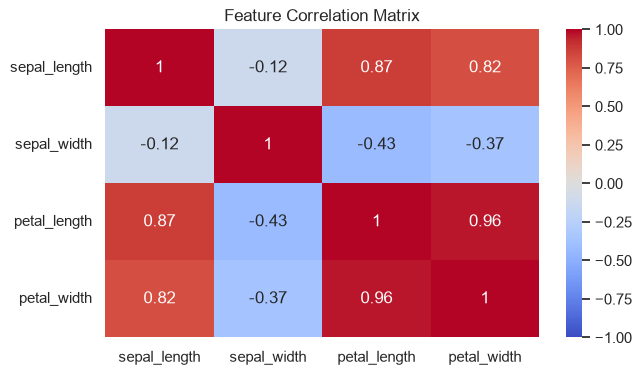

In [18]:
corr = iris.drop(columns=["species"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()

### Correlation Heatmap

A correlation heatmap visualizes the relationship between numerical features using correlation coefficients.

```python
corr = iris.drop(columns=["species"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
```

**Explanation:**

- `iris.drop(columns=["species"])` removes the categorical column since correlation is calculated only for numerical variables.
- `.corr()` computes the correlation matrix.
- `annot=True` displays correlation values inside each cell.
- `cmap="coolwarm"` uses colors to represent correlation strength:
  - Red → Positive correlation
  - Blue → Negative correlation
- `vmin=-1, vmax=1` fixes the color scale between -1 and 1.

**Correlation Values:**

- `+1` → Perfect positive correlation
- `0` → No correlation
- `-1` → Perfect negative correlation

**Key Observation:**

Features with correlation values close to **1** or **-1** have a strong relationship, while values near **0** indicate a weak or no relationship.

### Some more usefull plots

### Count Plot

A count plot displays the frequency (count) of observations in each category.

```python
sns.countplot(data=iris, x="species")
plt.title("Count of Each Iris Species")
plt.show()
```

**Purpose:**

- Shows the number of observations in each category.
- Useful for checking class balance in a dataset.

**Interpretation:**

- Each bar represents a category.
- Bar height indicates the number of records in that category.

**Key Observation (Iris Dataset):**

All three species (Setosa, Versicolor, Virginica) have 50 observations each, indicating a balanced dataset.

### Pair Plot

A pair plot visualizes pairwise relationships between numerical features in a dataset.

```python
sns.pairplot(iris, hue="species")
plt.show()
```

**Purpose:**

- Shows relationships between all numerical features.
- Helps identify patterns, clusters, and feature separability.
- Useful during Exploratory Data Analysis (EDA).

**Components:**

- **Off-diagonal plots:** Scatter plots showing relationships between feature pairs.
- **Diagonal plots:** Histograms/KDE plots showing individual feature distributions.
- **hue="species":** Colors points by species for easy comparison.

**Interpretation:**

- Points that form clear clusters indicate good class separation.
- Overlapping clusters may indicate features that are less useful for classification.

**Key Observation (Iris Dataset):**

Petal length and petal width clearly separate the three species, making them strong features for classification.

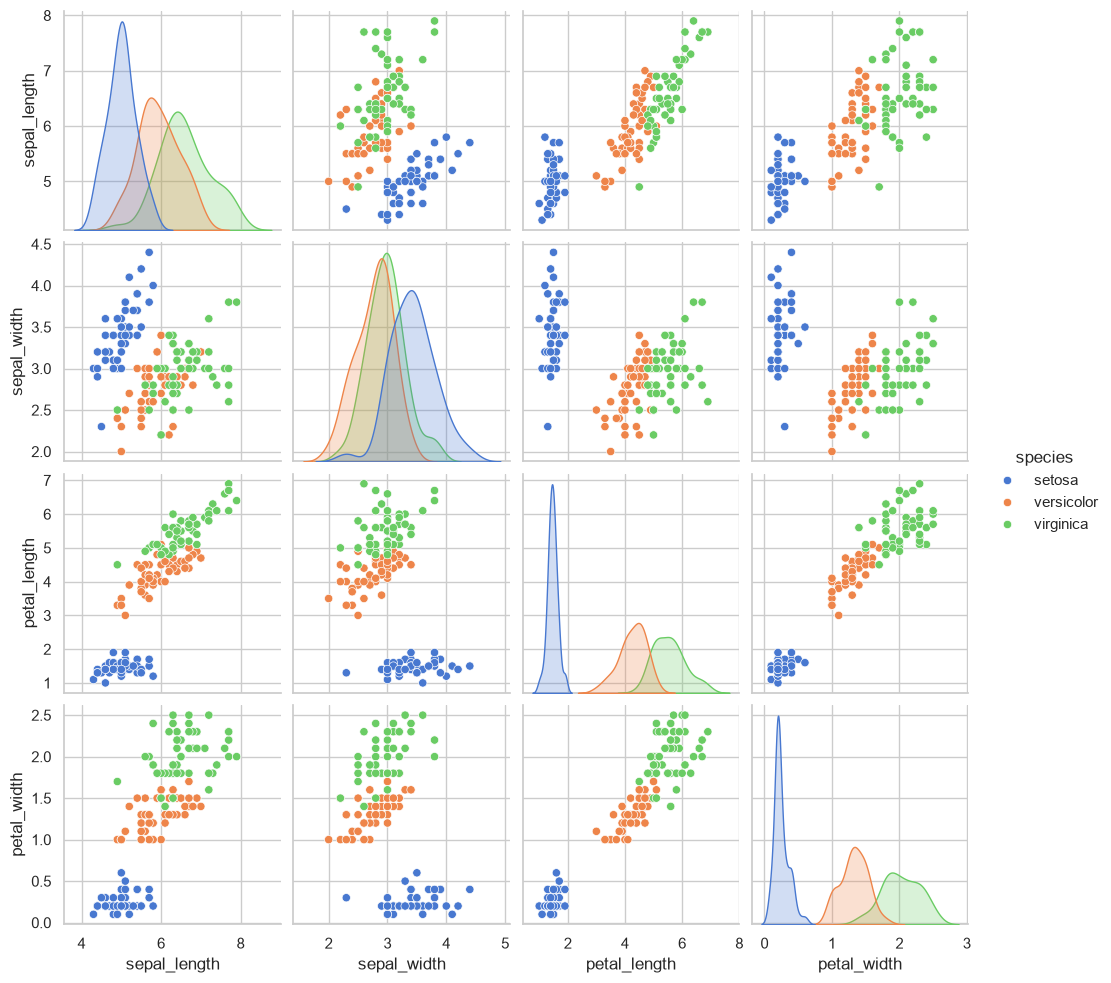

In [13]:
sns.pairplot(iris, hue="species")
plt.show()